In [256]:
!pip install openpyxl

In [257]:
import pandas as pd
import numpy as np
import re

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import pickle



In [258]:
from google.colab import files
uploaded = files.upload()

Saving BASE DE DADOS PEDE 2024 - DATATHON.xlsx to BASE DE DADOS PEDE 2024 - DATATHON (4).xlsx


In [259]:
df = pd.read_excel("BASE DE DADOS PEDE 2024 - DATATHON.xlsx")

df.head()

,RA,Fase,Turma,Nome,Idade 22,Gênero,ano_pede,Pedra,INDE,IAA,...,IPS,IPP,IDA,Matem,Portug,Inglês,IPV,IAN,Fase ideal,Defas
0,RA-1,7,A,Aluno-1,19,Menina,2022,Quartzo,5.783,8.3,...,5.6,NaN,4.0,2.7,3.5,6.0,7.278,5.0,Fase 8 (Universitários),-1
1,RA-2,7,A,Aluno-2,17,Menina,2022,Ametista,7.055,8.8,...,6.3,NaN,6.8,6.3,4.5,9.7,6.778,10.0,Fase 7 (3º EM),0
2,RA-3,7,A,Aluno-3,17,Menina,2022,Ágata,6.591,0.0,...,5.6,NaN,5.6,5.8,4.0,6.9,7.556,10.0,Fase 7 (3º EM),0
3,RA-4,7,A,Aluno-4,17,Menino,2022,Quartzo,5.951,8.8,...,5.6,NaN,5.0,2.8,3.5,8.7,5.278,10.0,Fase 7 (3º EM),0
4,RA-5,7,A,Aluno-5,17,Menina,2022,Ametista,7.427,7.9,...,5.6,NaN,5.2,7.0,2.9,5.7,7.389,10.0,Fase 7 (3º EM),0


In [260]:
print("Dimensão da base:")
print(df.shape)

df.info()

df.describe()

df.isnull().sum()

Dimensão da base:
(2845, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2845 entries, 0 to 2844
Data columns (total 21 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   RA          2845 non-null   object 
 1   Fase        2845 non-null   object 
 2   Turma       2845 non-null   object 
 3   Nome        2845 non-null   object 
 4   Idade 22    2845 non-null   int64  
 5   Gênero      2845 non-null   object 
 6   ano_pede    2845 non-null   int64  
 7   Pedra       2845 non-null   object 
 8   INDE        2845 non-null   float64
 9   IAA         2845 non-null   float64
 10  IEG         2845 non-null   float64
 11  IPS         2845 non-null   float64
 12  IPP         1985 non-null   float64
 13  IDA         2845 non-null   float64
 14  Matem       2839 non-null   float64
 15  Portug      2838 non-null   float64
 16  Inglês      1084 non-null   float64
 17  IPV         2845 non-null   float64
 18  IAN         2845 non-null   float64
 19

,0
RA,0
Fase,0
Turma,0
Nome,0
Idade 22,0
Gênero,0
ano_pede,0
Pedra,0
INDE,0
IAA,0


In [261]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

In [262]:
df["gênero"] = df["gênero"].replace({
    "Menina": "Feminino",
    "Menino": "Masculino"
})

df["genero_bin"] = df["gênero"].map({
    "Feminino":0,
    "Masculino":1
})

In [263]:
df["pedra"] = df["pedra"].replace({
    "Agata":"Ágata"
})

map_pedra = {
    "Quartzo":1,
    "Ágata":2,
    "Ametista":3,
    "Topázio":4
}

df["pedra_num"] = df["pedra"].map(map_pedra)

In [264]:
def limpar_fase(x):

    x = str(x).upper()

    if "ALFA" in x:
        return 0

    if "FASE" in x:
        return int(re.findall(r'\d+', x)[0])

    try:
        return int(x)
    except:
        return np.nan

df["fase_num"] = df["fase"].apply(limpar_fase)

In [265]:
def extrair_fase_ideal(x):

    x = str(x).upper()

    if "ALFA" in x:
        return 0

    num = re.search(r'\d+', x)

    if num:
        return int(num.group())

    return np.nan

df["fase_ideal_num"] = df["fase_ideal"].apply(extrair_fase_ideal)

In [266]:
df["matem"].fillna(df["matem"].mean(), inplace=True)

df["portug"].fillna(df["portug"].mean(), inplace=True)

df["tem_ingles"] = df["inglês"].notna().astype(int)

df["inglês"].fillna(df["inglês"].mean(), inplace=True)

df["tem_ipp"] = df["ipp"].notna().astype(int)

df["ipp"].fillna(df["ipp"].median(), inplace=True)

/tmp/ipykernel_418/1089893149.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["matem"].fillna(df["matem"].mean(), inplace=True)
/tmp/ipykernel_418/1089893149.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

In [267]:
df["media_notas"] = df[["matem","portug","inglês"]].mean(axis=1)

In [268]:
df["engajamento_geral"] = df[["ieg","iaa","ips"]].mean(axis=1)

In [269]:
df["score_pedagogico"] = df[["ida","ipp","ian"]].mean(axis=1)

In [270]:
df["gap_fase"] = df["fase_num"] - df["fase_ideal_num"]

In [271]:
df["risco_defasagem"] = (df["defas"] < 0).astype(int)

In [272]:
def classificar_defas(x):

    if x < -1:
        return "Defasagem severa"

    elif x < 0:
        return "Defasagem moderada"

    elif x == 0:
        return "Adequado"

    else:
        return "Adiantado"

df["categoria_defasagem"] = df["defas"].apply(classificar_defas)

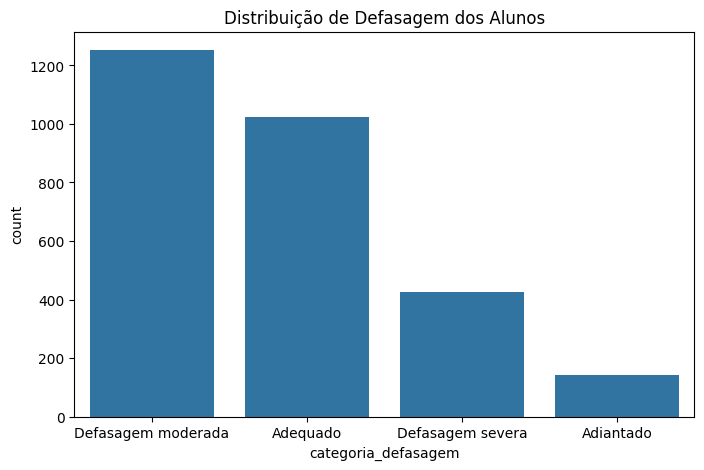

In [273]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="categoria_defasagem")

plt.title("Distribuição de Defasagem dos Alunos")

plt.show()

In [274]:
pd.DataFrame(X_train).isnull().sum()

X.isnull().sum()

,0
idade_22,0
genero_bin,0
ieg,0
ida,0
iaa,0
ips,0
ipp,0
ipv,0
media_notas,0
pedra_num,0


In [275]:
df[df["fase_num"].isnull()][["fase","fase_num"]].head(20)

,fase,fase_num
1987,1A,NaN
1988,1A,NaN
1989,1A,NaN
1990,1A,NaN
1991,1A,NaN
1992,1A,NaN
1993,1A,NaN
1994,1A,NaN
1995,1A,NaN
1996,1A,NaN


In [276]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [277]:
df["fase_num"].fillna(df["fase_ideal_num"], inplace=True)

df["gap_fase"] = df["fase_num"] - df["fase_ideal_num"]

X.isnull().sum()


/tmp/ipykernel_418/417342401.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["fase_num"].fillna(df["fase_ideal_num"], inplace=True)


,0
idade_22,0
genero_bin,0
ieg,0
ida,0
iaa,0
ips,0
ipp,0
ipv,0
media_notas,0
pedra_num,0


In [278]:
features = [

"idade_22",
"genero_bin",
"ieg",
"ida",
"iaa",
"ips",
"ipp",
"ipv",
"media_notas",
"pedra_num"

]

X = df[features]
y = df["risco_defasagem"]

In [279]:
X = df[features]
rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, n_estimators=300, random_state=42)

In [280]:
importancias = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importancias)

idade_22       0.204636
pedra_num      0.190487
media_notas    0.105547
ida            0.102705
ieg            0.087348
ipv            0.087098
ips            0.076598
iaa            0.068756
ipp            0.065026
genero_bin     0.011798
dtype: float64


In [281]:
X_train, X_test, y_train, y_test = train_test_split(

X,
y,
test_size=0.2,
random_state=42,
stratify=y

)

In [282]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [283]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import seaborn as sns

!pip install xgboost


In [284]:
def avaliar_modelo(nome_modelo, y_true, y_pred, y_prob):

    print(f"\n===== {nome_modelo} =====\n")

    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred))
    print("ROC AUC:", roc_auc_score(y_true, y_prob))

    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred))

    # Matriz de confusão
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

    plt.title(f"Matriz de Confusão - {nome_modelo}")
    plt.ylabel("Real")
    plt.xlabel("Previsto")

    plt.show()


===== Logistic Regression =====

Accuracy: 0.7539543057996485
Precision: 0.7865497076023392
Recall: 0.8005952380952381
F1 Score: 0.7935103244837758
ROC AUC: 0.8677191906805641

Classification Report:

              precision    recall  f1-score   support

           0       0.70      0.69      0.70       233
           1       0.79      0.80      0.79       336

    accuracy                           0.75       569
   macro avg       0.75      0.74      0.74       569
weighted avg       0.75      0.75      0.75       569



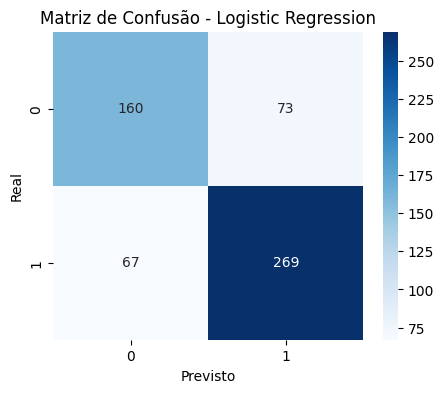

In [285]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

y_prob_log = log_model.predict_proba(X_test)[:,1]

avaliar_modelo(
    "Logistic Regression",
    y_test,
    y_pred_log,
    y_prob_log
)


===== Random Forest =====

Accuracy: 0.8295254833040422
Precision: 0.8292011019283747
Recall: 0.8958333333333334
F1 Score: 0.8612303290414879
ROC AUC: 0.8950413856529736

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.73      0.78       233
           1       0.83      0.90      0.86       336

    accuracy                           0.83       569
   macro avg       0.83      0.81      0.82       569
weighted avg       0.83      0.83      0.83       569



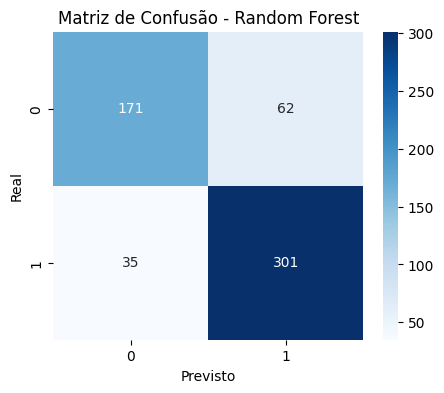

In [286]:
rf_model = RandomForestClassifier(

    n_estimators=300,
    max_depth=10,
    random_state=42

)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

y_prob_rf = rf_model.predict_proba(X_test)[:,1]

avaliar_modelo(
    "Random Forest",
    y_test,
    y_pred_rf,
    y_prob_rf
)


===== XGBoost =====

Accuracy: 0.8664323374340949
Precision: 0.8693181818181818
Recall: 0.9107142857142857
F1 Score: 0.8895348837209303
ROC AUC: 0.929235642754956

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.80      0.83       233
           1       0.87      0.91      0.89       336

    accuracy                           0.87       569
   macro avg       0.87      0.86      0.86       569
weighted avg       0.87      0.87      0.87       569



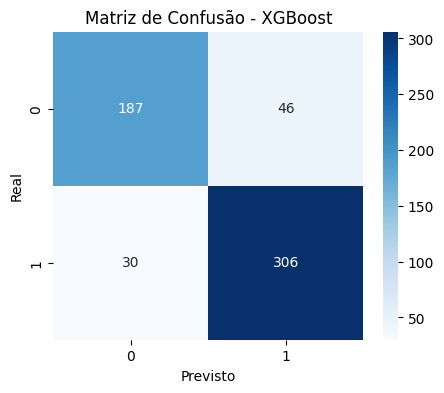

In [287]:
xgb_model = XGBClassifier(

    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"

)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

avaliar_modelo(
    "XGBoost",
    y_test,
    y_pred_xgb,
    y_prob_xgb
)

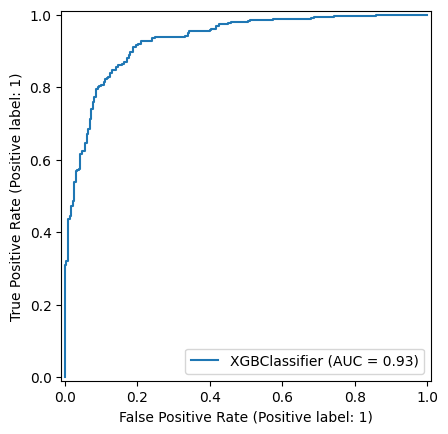

In [288]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(xgb_model, X_test, y_test)


<Axes: >

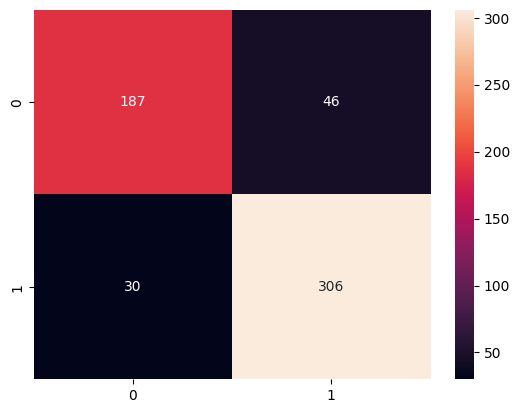

In [289]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_xgb)

sns.heatmap(cm, annot=True, fmt="d")

In [290]:
resultados = pd.DataFrame({

"Modelo":[
    "Logistic Regression",
    "Random Forest",
    "XGBoost"
],

"Accuracy":[
    accuracy_score(y_test, y_pred_log),
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_xgb)
],

"Precision":[
    precision_score(y_test, y_pred_log),
    precision_score(y_test, y_pred_rf),
    precision_score(y_test, y_pred_xgb)
],

"Recall":[
    recall_score(y_test, y_pred_log),
    recall_score(y_test, y_pred_rf),
    recall_score(y_test, y_pred_xgb)
],

"F1":[
    f1_score(y_test, y_pred_log),
    f1_score(y_test, y_pred_rf),
    f1_score(y_test, y_pred_xgb)
],

"AUC":[
    roc_auc_score(y_test, y_prob_log),
    roc_auc_score(y_test, y_prob_rf),
    roc_auc_score(y_test, y_prob_xgb)
]

})

resultados.sort_values("AUC", ascending=False)

,Modelo,Accuracy,Precision,Recall,F1,AUC
2,XGBoost,0.866432,0.869318,0.910714,0.889535,0.929236
1,Random Forest,0.829525,0.829201,0.895833,0.861230,0.895041
0,Logistic Regression,0.753954,0.786550,0.800595,0.793510,0.867719


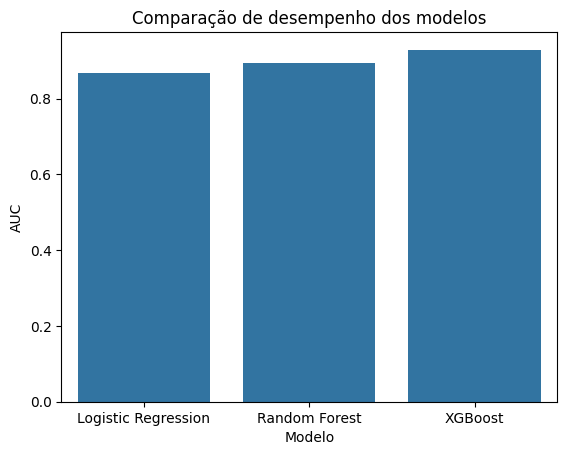

In [291]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=resultados, x="Modelo", y="AUC")

plt.title("Comparação de desempenho dos modelos")

plt.show()

In [292]:
pd.crosstab(df["pedra_num"], df["risco_defasagem"])

risco_defasagem,0,1
pedra_num,,
1,54,262
2,161,560
3,453,667
4,498,190


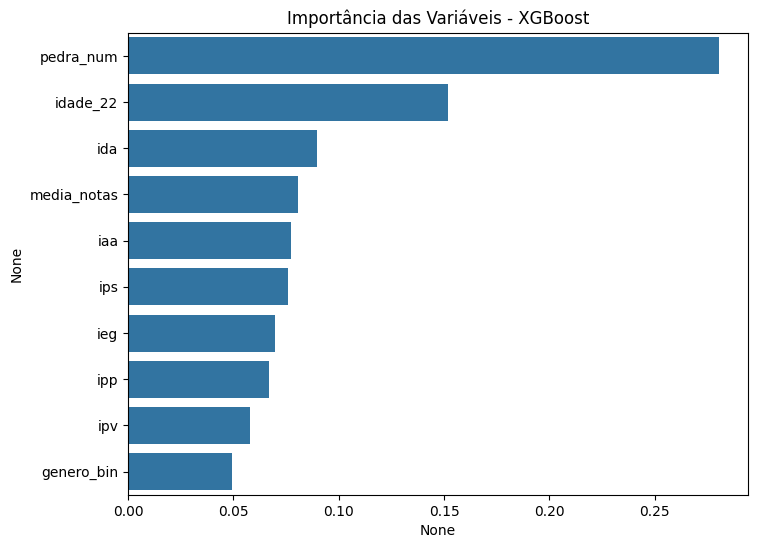

In [293]:
importancias = pd.Series(
    xgb_model.feature_importances_,
    index=features
).sort_values(ascending=False)

plt.figure(figsize=(8,6))

sns.barplot(
    x=importancias,
    y=importancias.index
)

plt.title("Importância das Variáveis - XGBoost")

plt.show()

<Axes: xlabel='risco_defasagem', ylabel='count'>

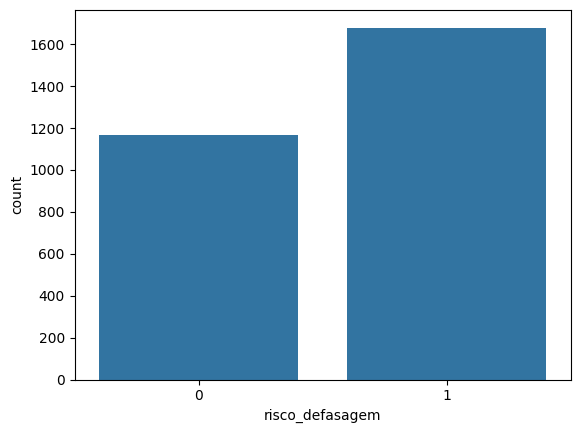

In [294]:
sns.countplot(x=df["risco_defasagem"])

In [295]:
from google.colab import files

df.to_excel("base_tratada.xlsx", index=False)

files.download("base_tratada.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [297]:
configuracao = {

    "features_modelo": list(X.columns),

    "variavel_target": "risco_defasagem",

    "modelo_utilizado": "XGBoost",

    "metricas": {
        "AUC": 0.93
    },

    "descricao": "Modelo de predição de risco de defasagem educacional"
}

with open("Configuracao_passosMagicos.pkl", "wb") as f:
    pickle.dump(configuracao, f)

print("Configuração salva com sucesso!")

Configuração salva com sucesso!


In [300]:
with open("Modelo_passosMagicos.pkl", "wb") as f:
    pickle.dump(xgb_model, f)

print("Modelo salvo com sucesso!")

Modelo salvo com sucesso!


In [301]:
from google.colab import files

files.download("Modelo_passosMagicos.pkl")
files.download("Configuracao_passosMagicos.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>